# Assignment M2, Preprocessing Part 2
**George Khramtchenko - University of Connecticut**

-------------------------------------
The work contained and presented here is my work and my work alone. The following sources were used:
*   OPIM 5604 Module 2 Preprocessing.ipynb
*   pandas.pydata.org/docs/reference
*   Google Gemini
*   StackOverflow


# Environment Setup

In [ ]:
# Import Modules

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

!pip install scikit-learn
from sklearn.preprocessing import PowerTransformer

# Set display options to show all columns
pd.set_option('display.max_columns', None)


In [ ]:
# Mount my google drive for access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Prompt 1:** Read in the dataset and determine how many rows and columns it has

In [ ]:
# Initially, an encoding error prevented the code from running due to an issue with reading the encoding. Encoding handling was added for 'latin-1'.
try:
    df = pd.read_csv('/content/drive/MyDrive/UConn/OPIM-5604-Predictive-Modeling/Module 2/Assignment M2/spotify-2023.csv', encoding='latin-1')
    # Obtain the number of rows and columns this data has
    print(df.shape)

except UnicodeDecodeError:
    print("UnicodeDecodeError: Failed to decode the file using 'latin-1' encoding.")

(953, 24)


This dataset has **953** rows and **24** columns.

Print the head elements of each column row for initial data visualization.

In [74]:
print(df.head())

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_month  released_day  in_spotify_playlists  in_spotify_charts  \
0               7            14                   553                147   
1               3            23                  1474                 48   
2               6            30                  1397                113   
3               8            23                  7858                100   
4               5            18                  3133                 50   

     streams  in_apple_playlists  in_apple_charts  bpm key   mode  \
0  141381703                 

**Prompt 2:** The target variable for this dataset is the streams column. Check the datatype of streams. If it isn’t already int64, update it. Hint: if needed, drop a row of problematic data to get it to convert properly.



In [86]:
# View the data types of the columns
print(f"View the data types of the columns before any required changes are implemented, if necessary: \n{df.dtypes}")

# Previous code block execution attempts had failed and yielded row(s) of problematic data
# Locate and remove the problematic row(s) of data before type conversion from obj to int86
# Utilizing the 'errors='coerce' allows the missing data to be converted into a NaN without raising an exception
problematic_rows = df[pd.to_numeric(df['streams'], errors='coerce').isna()]
if not problematic_rows.empty:
    print(f"\nFound problematic row(s) in 'streams' column: {problematic_rows}")
    df.drop(problematic_rows.index, inplace=True)
    print(f"\nDropped {len(problematic_rows)} problematic row(s).")

# Once all rows with the problematic data have been dropped,
# attempt conversion from 'object' to 'int64' for the 'streams' column
# Display the data type of the 'streams' column and the head for verification
try:
    df['streams'] = df['streams'].astype('int64')
    print(f"\nUpon data correction, the 'streams' column was successfully converted to type: {df['streams'].dtypes}.")
    print(f"View the head of the 'streams' column: \n{df['streams'].head()}")

# Basic error handling
except ValueError as vr:
    print(f"\n Conversion of 'streams' column to int64 after dropping problematic row(s) failed: {vr}")

View the data types of the columns before any required changes are implemented, if necessary: 
track_name                             object
artist(s)_name                         object
artist_count                            int64
released_month                          int64
released_day                            int64
in_spotify_playlists                    int64
in_spotify_charts                       int64
streams                                 int64
in_apple_playlists                      int64
in_apple_charts                         int64
bpm                                     int64
key                                    object
mode                                   object
danceability_%                          int64
valence_%                               int64
energy_%                                int64
acousticness_%                          int64
liveness_%                              int64
speechiness_%                           int64
Streams_Bin                    

**Prompt 3:** Check the remaining variables. Do any other columns need their data type updated?

In [90]:
print(f"View the current column data types before any required changes are implemented: \n{df.dtypes}\n")

# Convert the defined list of columns to int64 type; convert each column type if it exists
columns_to_convert = ['in_deezer_playlists', 'in_shazam_charts']
for column in columns_to_convert:
    if column in df.columns:
        try:
            # Based on my code analysis, two errors were present: comma use and NaN values.
            # First, I removed all commas from all problematic numbers by conversion to string
            # Next, I replaced the NaN string with a value of zero to be able to convert it to 'int64'
            # Finally, I performed the column conversion
            df[column] = df[column].astype(str).str.replace(',', '', regex=False)
            df[column] = pd.to_numeric(df[column], errors='coerce').astype('int64')
            print(f"Converted column '{column}' to int64 type.")
        except ValueError as e:
            print(f"Conversion of '{column}' to int64 after data cleaning failed: {e}")
    else:
        print(f"Column '{column}' not found in the DataFrame.")

# Verify the data type for the targeted columns was successful
# Source: Generated by Google Gemini
print("\nView the data types of the columns after attempted changes:")
print(df[columns_to_convert].dtypes if all(col in df.columns for col in columns_to_convert) else "Columns not found")

# Display the head of the first column in the list (if it was converted and exists)
# Source: Generated by Google Gemini
if columns_to_convert and columns_to_convert[0] in df.columns and df[columns_to_convert[0]].dtype == 'int64':
    print(f"\nHead of '{columns_to_convert[0]}':\n{df[columns_to_convert[0]].head()}")

View the current column data types before any required changes are implemented: 
track_name                             object
artist(s)_name                         object
artist_count                            int64
released_month                          int64
released_day                            int64
in_spotify_playlists                    int64
in_spotify_charts                       int64
streams                                 int64
in_apple_playlists                      int64
in_apple_charts                         int64
bpm                                     int64
key                                    object
mode                                   object
danceability_%                          int64
valence_%                               int64
energy_%                                int64
acousticness_%                          int64
liveness_%                              int64
speechiness_%                           int64
Streams_Bin                          category

**Prompt 4:** Practice binning in_spotify_playlists.

In [96]:
# View columns prior to data manipulation
print(df.head())

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_month  released_day  in_spotify_playlists  in_spotify_charts  \
0               7            14                   553                147   
1               3            23                  1474                 48   
2               6            30                  1397                113   
3               8            23                  7858                100   
4               5            18                  3133                 50   

     streams  in_apple_playlists  in_apple_charts  bpm key   mode  \
0  141381703                 

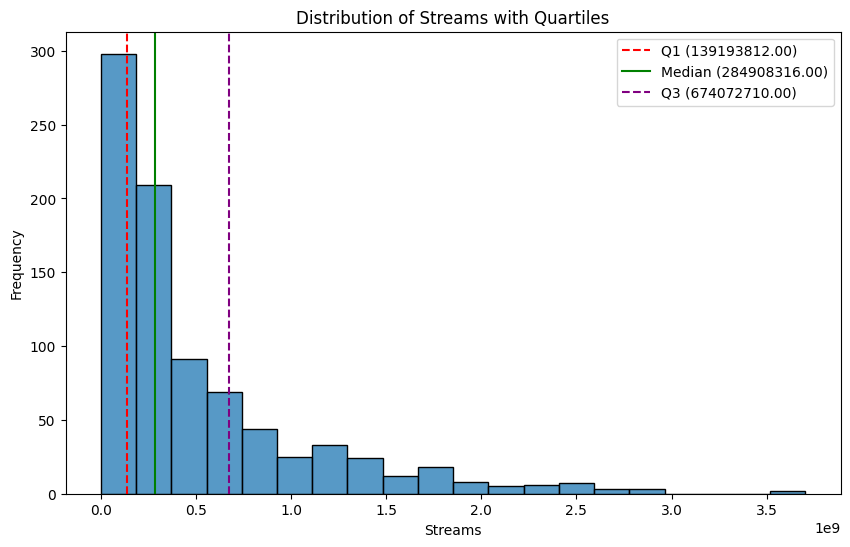

In [95]:
# Show a histogram of streams with quartiles to get an idea of bin size
plt.figure(figsize=(10, 6))

# Create the histogram
sns.histplot(data=df, x='streams', bins=20)

plt.title('Distribution of Streams with Quartiles')
plt.xlabel('Streams')
plt.ylabel('Frequency')

# Calculate the quartiles
q1 = df['streams'].quantile(0.25)
q2 = df['streams'].quantile(0.50) # Median
q3 = df['streams'].quantile(0.75)

# Add vertical lines for the quartiles
plt.axvline(q1, color='red', linestyle='--', label=f'Q1 ({q1:.2f})')
plt.axvline(q2, color='green', linestyle='-', label=f'Median ({q2:.2f})')
plt.axvline(q3, color='purple', linestyle='--', label=f'Q3 ({q3:.2f})')

# Add a legend to show the labels for the lines
plt.legend()

plt.show()

     streams Streams_Bin
0  141381703         Few
1  133716286         Few
2  140003974         Few
3  800840817        Many
4  303236322    Moderate

Distribution of Streams Bins:
Streams_Bin
Moderate    421
Few         221
Many        215
Name: count, dtype: int64


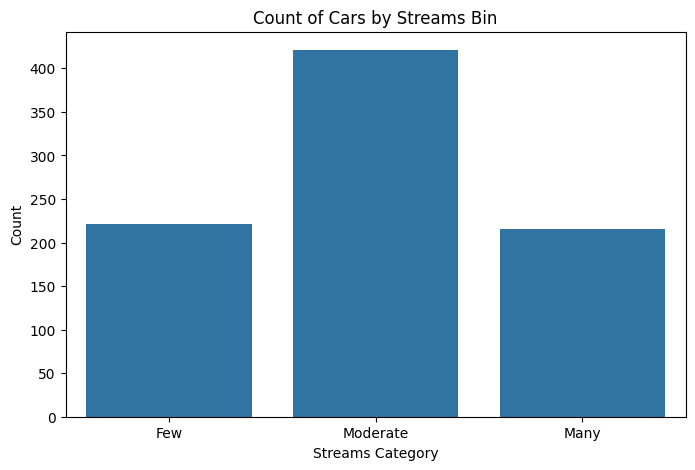

In [94]:
# Bin the streams column into ranges for few streams, moderate streams, and many streams
bins = [0, 141636175, 673869022, df['streams'].max()]
labels = ['Few', 'Moderate', 'Many']

# Create a new column 'Streams_Bin' by binning the 'streams' column
df['Streams_Bin'] = pd.cut(df['streams'], bins=bins, labels=labels, right=True)

# Display the first few rows with the new column
print(df[['streams', 'Streams_Bin']].head())

# Display the distribution of the new 'Streams_Bin' column
print("\nDistribution of Streams Bins:")
print(df['Streams_Bin'].value_counts())

# Optionally, visualize the distribution of the new bin
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Streams_Bin', order=labels)
plt.title('Count of Cars by Streams Bin')
plt.xlabel('Streams Category')
plt.ylabel('Count')
plt.show()

**Prompt 5:** Practice making dummy variables for the key column.

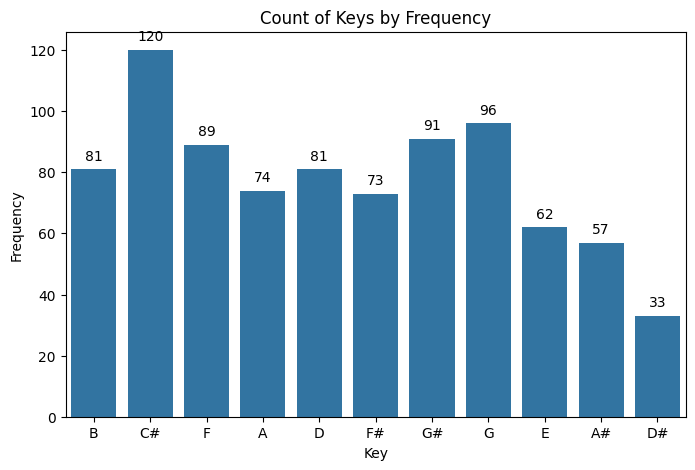

In [93]:
# Show a histogram of the 'key' variable
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='key')

plt.title('Count of Keys by Frequency')
plt.xlabel('Key')
plt.ylabel('Frequency')

# Add value labels to the bars
for p in ax.patches:
    height = p.get_height() # Get the height of each bar (which represents the count)
    ax.text(p.get_x() + p.get_width()/2., # X-coordinate for the text (center of the bar)
            height + 3, # Y-coordinate for the text (slightly above the top of the bar)
            '{:1.0f}'.format(height), # The text to display (the count)
            ha="center") # Horizontal alignment of the text (center)

plt.show()

In [92]:
# Make dummy variables for the 'key' column
# 'drop_first=True' drops the first category to avoid multicollinearity (n-1 dummies)

# Create dummy variables, but do NOT drop the original column yet
key_dummies = pd.get_dummies(df['key'], drop_first=True, dtype=float)

# Rename columns to be more descriptive (optional but recommended)
key_dummies.columns = [f'key{col}' for col in key_dummies.columns]

# Concatenate the original DataFrame with the new dummy variables DataFrame
df = pd.concat([df, key_dummies], axis=1)

# Display the first few rows to see the original and new dummy columns
print(df.head())

# Display the columns to see the original and new dummy variables
print("\nColumns after creating dummy variables for key column:")
df.columns

                            track_name    artist(s)_name  artist_count  \
0  Seven (feat. Latto) (Explicit Ver.)  Latto, Jung Kook             2   
1                                 LALA       Myke Towers             1   
2                              vampire    Olivia Rodrigo             1   
3                         Cruel Summer      Taylor Swift             1   
4                       WHERE SHE GOES         Bad Bunny             1   

   released_month  released_day  in_spotify_playlists  in_spotify_charts  \
0               7            14                   553                147   
1               3            23                  1474                 48   
2               6            30                  1397                113   
3               8            23                  7858                100   
4               5            18                  3133                 50   

     streams  in_apple_playlists  in_apple_charts  bpm key   mode  \
0  141381703                 

Index(['track_name', 'artist(s)_name', 'artist_count', 'released_month',
       'released_day', 'in_spotify_playlists', 'in_spotify_charts', 'streams',
       'in_apple_playlists', 'in_apple_charts', 'bpm', 'key', 'mode',
       'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
       'liveness_%', 'speechiness_%', 'Streams_Bin', 'keyC#', 'keyF', 'keyG',
       'keyG#', 'in_spotify_playlists_Standardized',
       'in_spotify_playlists_Scaled', 'in_spotify_playlists_JohnsonSU',
       'key_reduced', 'keyA#', 'keyB', 'keyC#', 'keyD', 'keyD#', 'keyE',
       'keyF', 'keyF#', 'keyG', 'keyG#'],
      dtype='object')

In [ ]:
# Show a frequency table for keyB, keyC#, keyF#
print("Frequency Table for Keys:")
print(df[['keyB', 'keyC#', 'keyF#']].value_counts().sort_index())

Frequency Table for Key Types:
keyB  keyC#  keyF#
0.0   0.0    0.0      678
             1.0       73
      1.0    0.0      120
1.0   0.0    0.0       81
Name: count, dtype: int64


**Prompt 6:** Find the missing values in the dataset and handle them appropriately.

In [91]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# Check the total number of missing values in the DataFrame
print("\nTotal missing values in the dataset:")
print(df.isnull().sum().sum())

# Find the index of rows with missing values in the 'key' column
missing_key_indices = df[df['key'].isnull()].index

# Drop the rows with missing 'key' values
df.drop(missing_key_indices, inplace=True)

# Verify that the rows have been dropped by checking for missing 'key' values again
print("\nMissing values after dropping rows with missing key:")
print(df.isnull().sum())

# Verify the new shape of the DataFrame
print("\nShape of DataFrame after dropping rows with missing key:")
df.shape

Missing values per column:
track_name                           0
artist(s)_name                       0
artist_count                         0
released_month                       0
released_day                         0
in_spotify_playlists                 0
in_spotify_charts                    0
streams                              0
in_apple_playlists                   0
in_apple_charts                      0
bpm                                  0
key                                  0
mode                                 0
danceability_%                       0
valence_%                            0
energy_%                             0
acousticness_%                       0
liveness_%                           0
speechiness_%                        0
Streams_Bin                          0
keyC#                                0
keyF                                 0
keyG                                 0
keyG#                                0
in_spotify_playlists_Standardized    

(857, 28)

**Prompt 7:** Find the potential outliers in the dataset and handle them appropriately.

In [ ]:
## Detecting Outliers in All Numeric Columns

# Select only the numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Iterate through each numeric column to find outliers
for col in numeric_cols:
    print(f"Checking for outliers in column: {col}")

    # Calculate interquartile range (IQR)
    q1 = df[col].quantile(0.1)
    q3 = df[col].quantile(0.9)
    iqr = q3 - q1

    # Define the boundaries for an outlier
    lower_bound = q1 - (3 * iqr)
    upper_bound = q3 + (3 * iqr)

    # Find the outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Display the outliers for the current column
    if not outliers.empty:
        print(f"Outliers found in {col}: {len(outliers)} outliers")
        # Display only the outlier values from the current column
        print(outliers[col])
    else:
        print(f"No outliers found in {col} using the quantile range method.")
    print("-" * 30) # Separator for clarity between columns

Checking for outliers in column: artist_count
No outliers found in artist_count using the quantile range method.
------------------------------
Checking for outliers in column: released_year
Outliers found in released_year: 21 outliers
80     1975
425    1973
439    1930
443    1958
444    1957
447    1963
448    1959
451    1970
454    1963
457    1971
460    1946
461    1979
466    1950
469    1942
471    1963
476    1958
483    1959
495    1958
496    1957
840    1982
922    1982
Name: released_year, dtype: int64
------------------------------
Checking for outliers in column: released_month
No outliers found in released_month using the quantile range method.
------------------------------
Checking for outliers in column: released_day
No outliers found in released_day using the quantile range method.
------------------------------
Checking for outliers in column: in_spotify_playlists
No outliers found in in_spotify_playlists using the quantile range method.
--------------------------

ValueError: Could not interpret value `released_year` for `x`. An entry with this name does not appear in `data`.

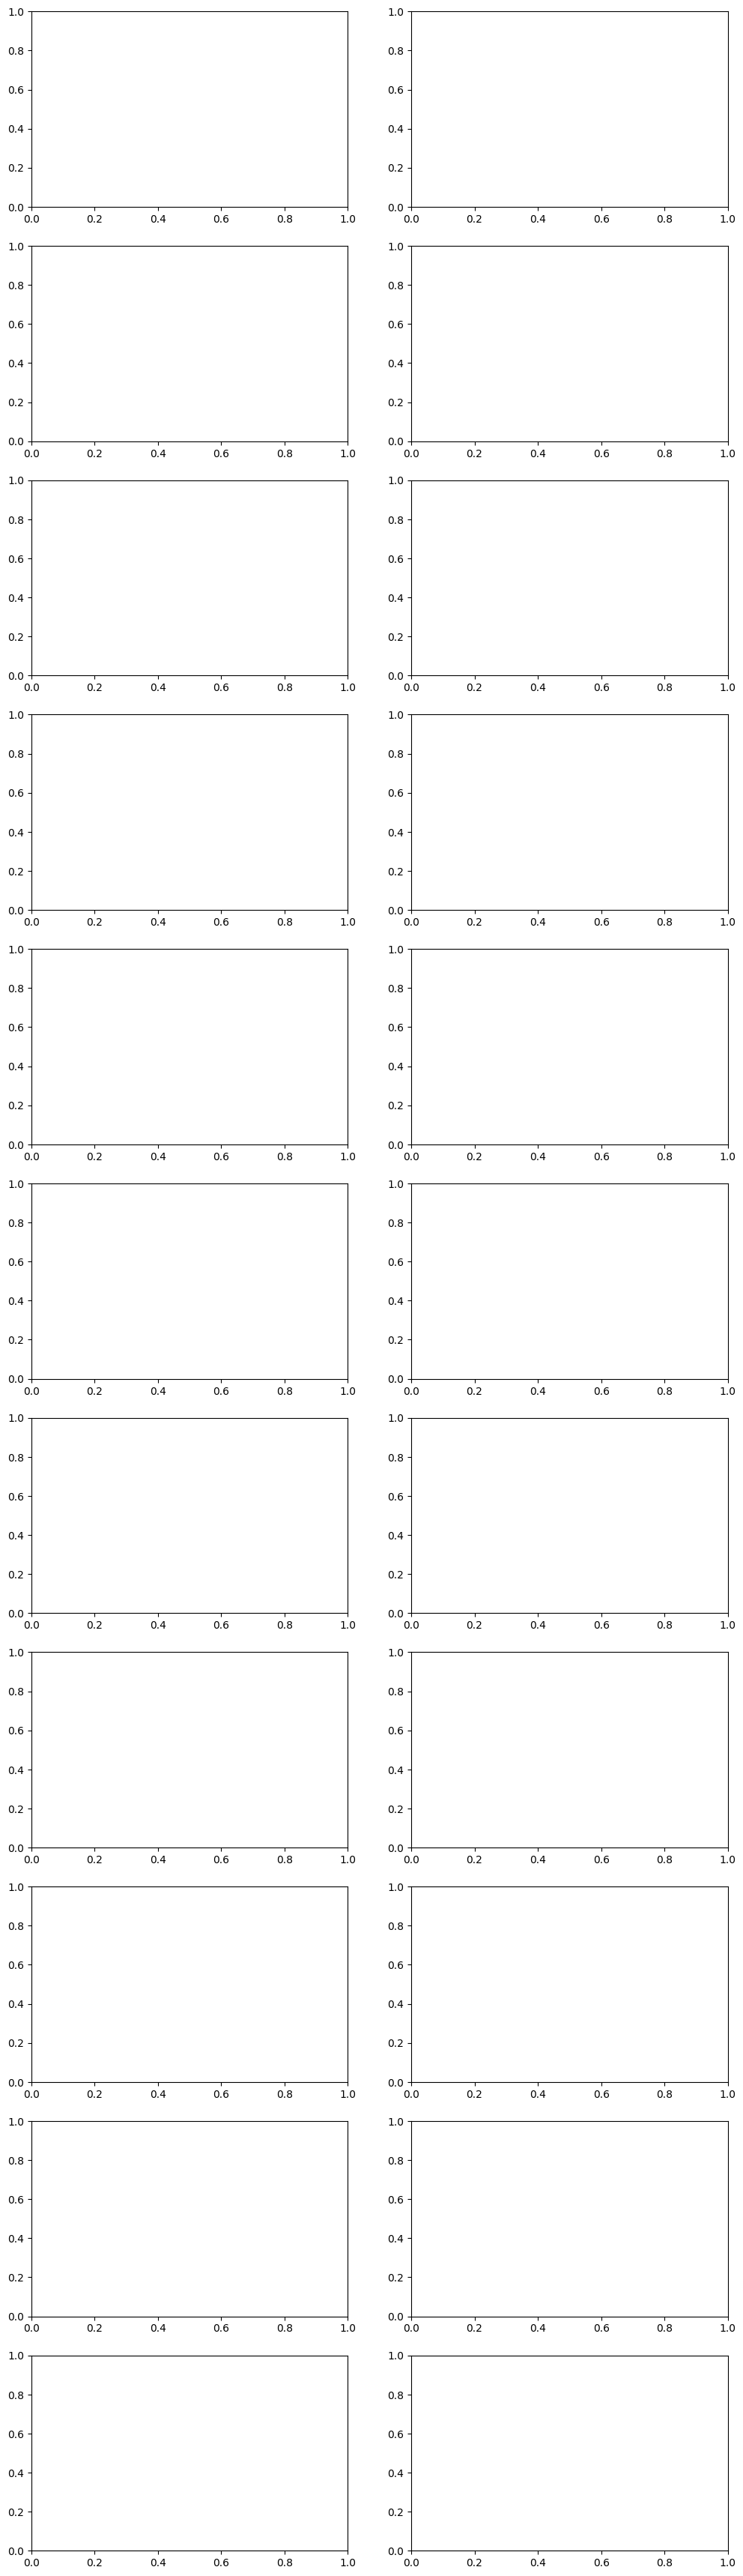

In [97]:
# Columns for plotting the outliers for inspection
cols_to_plot = ['released_year', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts',
                'instrumentalness_%', 'keyA#', 'keyB', 'keyD', 'keyD#', 'keyE', 'keyF#']

# Create subplots for histograms and box plots side by side
fig, axes = plt.subplots(len(cols_to_plot), 2, figsize=(12, 4 * len(cols_to_plot))) # 2 columns for hist and boxplot

for i, col in enumerate(cols_to_plot):
    # Histogram
    sns.histplot(data=df, x=col, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')

    # Box plot
    sns.boxplot(data=df, x=col, ax=axes[i, 1])
    axes[i, 1].set_title(f'Box Plot of {col}')
    axes[i, 1].set_xlabel(col)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [63]:
# Drop this data due to zero or very little variability
cols_to_drop = ['released_year', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'keyA#', 'keyB', 'keyD', 'keyD#', 'keyE', 'keyF#']
df.drop(cols_to_drop, axis=1, inplace=True)
print("\nColumns after dropping ALL outlier data columns:")
print(df.columns)
print("\nShape of DataFrame after dropping ALL outlier data columns:")
df.shape

KeyError: "['released_year', 'in_deezer_playlists', 'in_deezer_charts', 'in_shazam_charts', 'keyA#', 'keyB', 'keyD', 'keyD#', 'keyE', 'keyF#'] not found in axis"

**Prompt 8:** Practice standardizing in_spotify_playlists.

   in_spotify_playlists  in_spotify_playlists_Standardized
0                   553                          -0.585596
1                  1474                          -0.469660
2                  1397                          -0.479353
3                  7858                           0.333962
4                  3133                          -0.260824


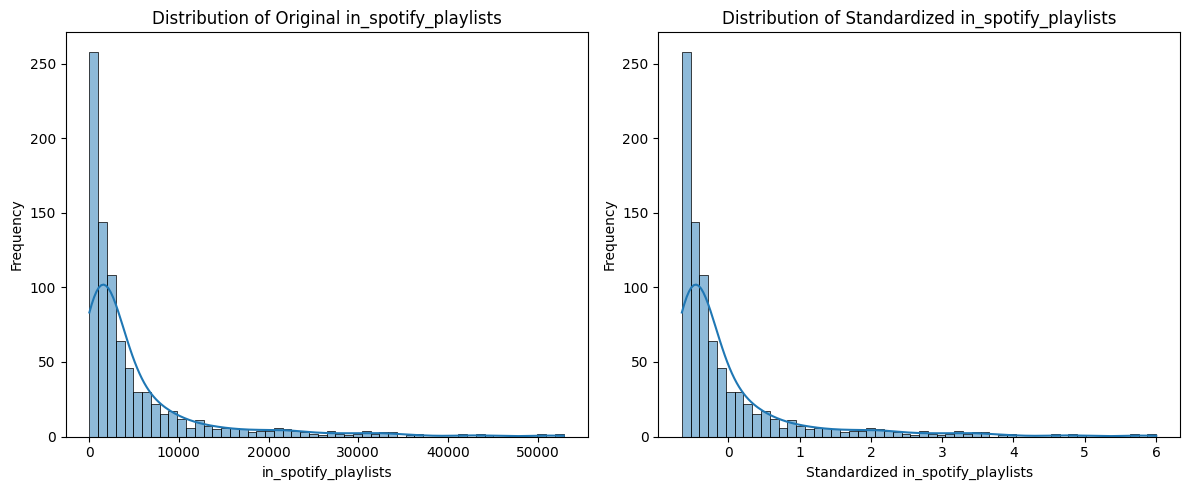

In [98]:
# Standardize the 'in_spotify_playlists' column using Z-scores
df['in_spotify_playlists_Standardized'] = (df['in_spotify_playlists'] - df['in_spotify_playlists'].mean()) / df['in_spotify_playlists'].std()

# Display the head with the original and standardized 'in_spotify_playlists' columns
print(df[['in_spotify_playlists', 'in_spotify_playlists_Standardized']].head())

# Optionally, visualize the distribution of the original and standardized 'in_spotify_playlists' columns
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(data=df, x='in_spotify_playlists', kde=True)
plt.title('Distribution of Original in_spotify_playlists')
plt.xlabel('in_spotify_playlists')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(data=df, x='in_spotify_playlists_Standardized', kde=True)
plt.title('Distribution of Standardized in_spotify_playlists')
plt.xlabel('Standardized in_spotify_playlists')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

   in_spotify_playlists  in_spotify_playlists_Standardized  \
0                   553                          -0.585596   
1                  1474                          -0.469660   
2                  1397                          -0.479353   
3                  7858                           0.333962   
4                  3133                          -0.260824   

   in_spotify_playlists_Scaled  
0                     0.009874  
1                     0.027295  
2                     0.025838  
3                     0.148051  
4                     0.058676  


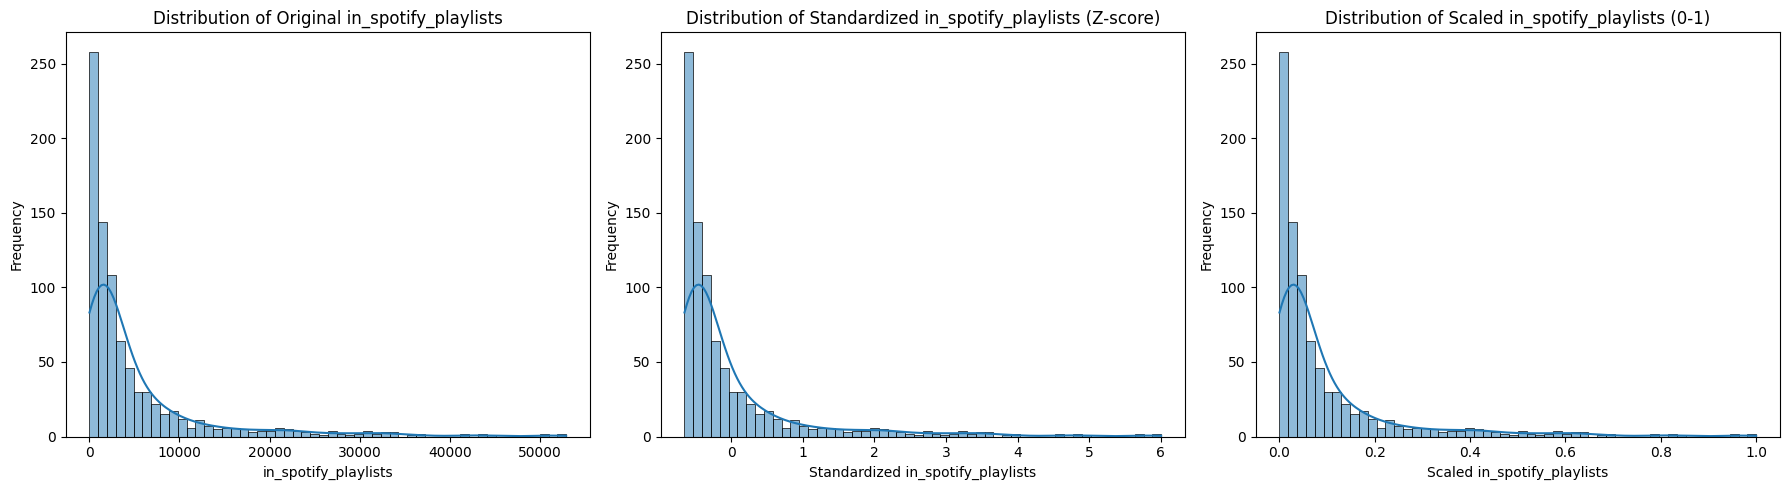

In [99]:
# Standardize the 'in_spotify_playlists' column using Min-Max scaling (0 to 1 scale)
df['in_spotify_playlists_Scaled'] = (df['in_spotify_playlists'] - df['in_spotify_playlists'].min()) / (df['in_spotify_playlists'].max() - df['in_spotify_playlists'].min())

# Display the head with the original, standardized, and scaled 'in_spotify_playlists' columns
print(df[['in_spotify_playlists', 'in_spotify_playlists_Standardized', 'in_spotify_playlists_Scaled']].head())

# Optionally, visualize the distribution of the original, standardized, and scaled 'in_spotify_playlists'
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1) # 1 row, 3 columns, 1st plot
sns.histplot(data=df, x='in_spotify_playlists', kde=True)
plt.title('Distribution of Original in_spotify_playlists')
plt.xlabel('in_spotify_playlists')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2) # 1 row, 3 columns, 2nd plot
sns.histplot(data=df, x='in_spotify_playlists_Standardized', kde=True)
plt.title('Distribution of Standardized in_spotify_playlists (Z-score)')
plt.xlabel('Standardized in_spotify_playlists')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3) # 1 row, 3 columns, 3rd plot
sns.histplot(data=df, x='in_spotify_playlists_Scaled', kde=True)
plt.title('Distribution of Scaled in_spotify_playlists (0-1)')
plt.xlabel('Scaled in_spotify_playlists')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Prompt 9:** Practice transforming in_spotify_playlists.

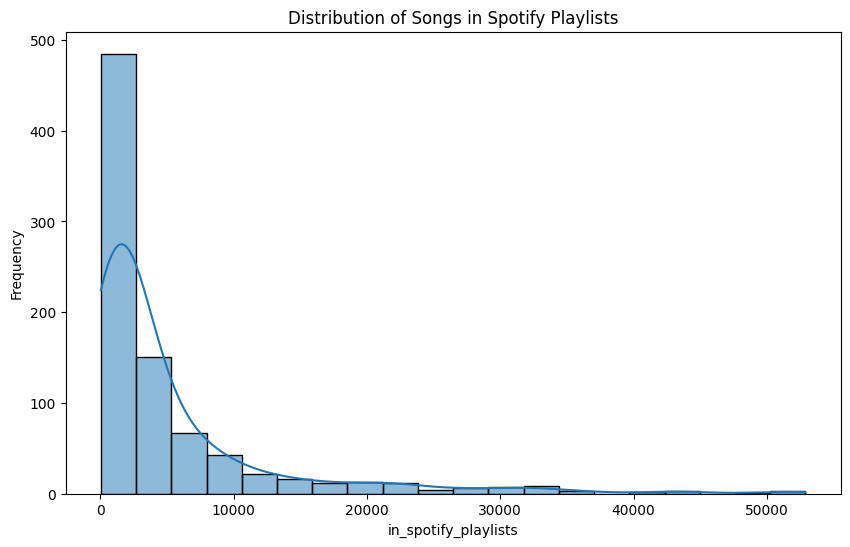

Text(0.5, 0, 'in_spotify_playlists')

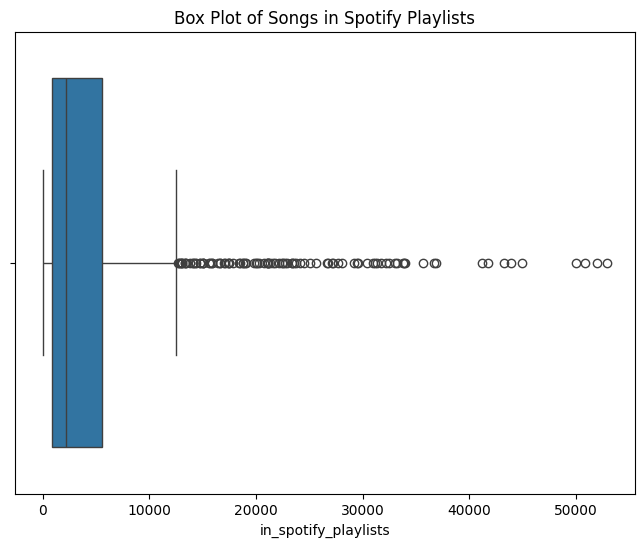

In [100]:
# Show a histogram of 'in_spotify_playlists' column with box plot
plt.figure(figsize=(10, 6))

# Create the histogram
sns.histplot(data=df, x='in_spotify_playlists', bins=20, kde=True) # Added kde=True for density curve

plt.title('Distribution of Songs in Spotify Playlists')
plt.xlabel('in_spotify_playlists')
plt.ylabel('Frequency')

plt.show()

# Create the box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='in_spotify_playlists')
plt.title('Box Plot of Songs in Spotify Playlists')
plt.xlabel('in_spotify_playlists')

   in_spotify_playlists  in_spotify_playlists_JohnsonSU
0                   553                       -1.042334
1                  1474                       -0.306378
2                  1397                       -0.346574
3                  7858                        0.942177
4                  3133                        0.257439


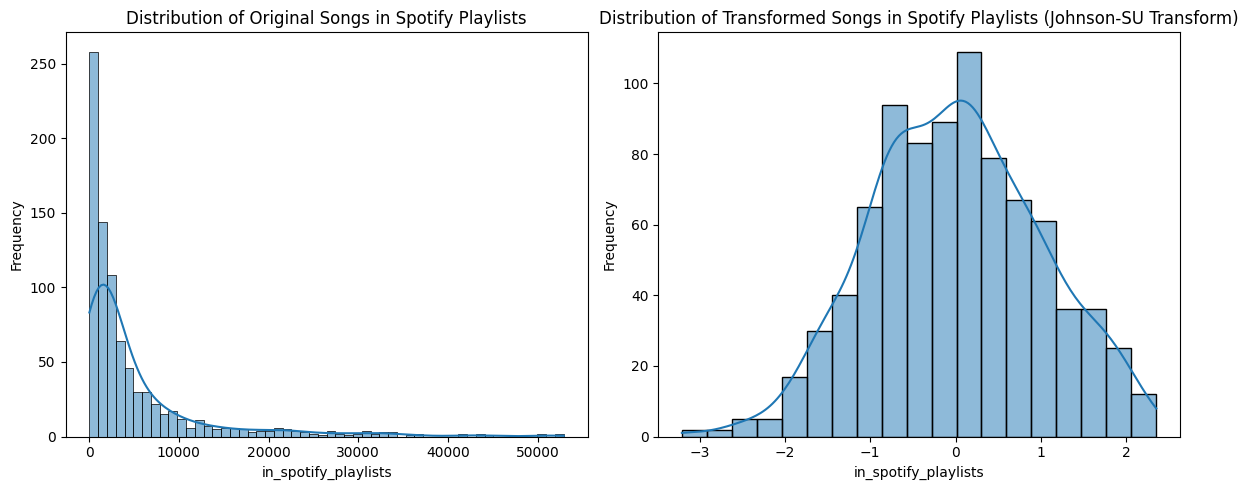

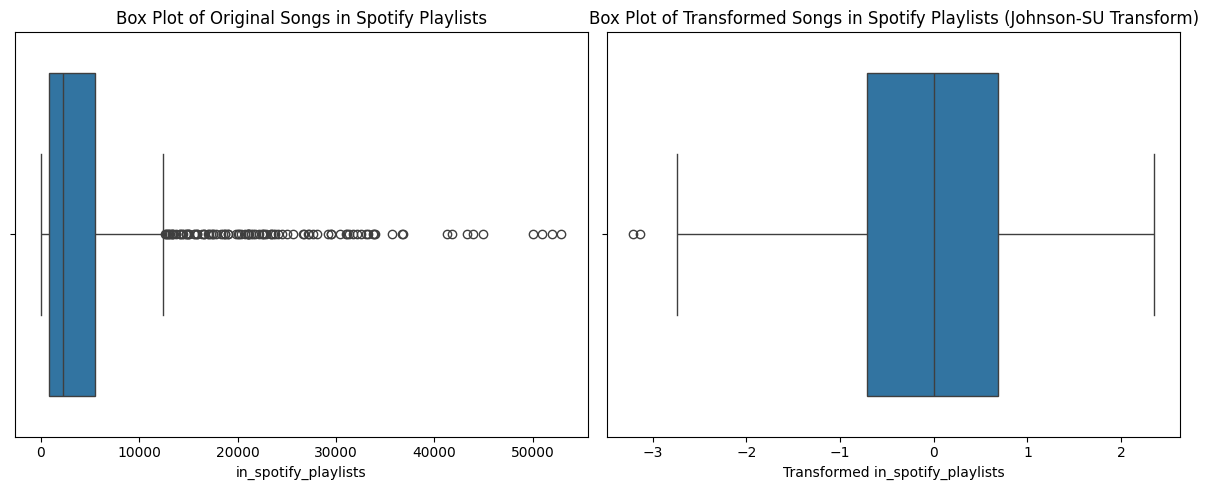

In [101]:
# Transform the in_spotify_playlists variable using the johnson su transform

# Initialize the PowerTransformer with the 'yeo-johnson' method
# The 'yeo-johnson' method can handle both positive and negative data
# For weight, which is always positive, 'box-cox' would also be suitable.
# However, 'yeo-johnson' is more general and safer if other variables might have zeros or negatives.
pt = PowerTransformer(method='yeo-johnson', standardize=True) # standardize=True makes the transformed data zero mean, unit variance

# Reshape the data to be a 2D array (required by transform)
in_spotify_playlists_reshaped = df['in_spotify_playlists'].values.reshape(-1, 1)

# Fit the transformer and transform the 'in_spotify_playlists' column
df['in_spotify_playlists_JohnsonSU'] = pt.fit_transform(in_spotify_playlists_reshaped)

# Display the head with the original and transformed 'in_spotify_playlists' columns
print(df[['in_spotify_playlists', 'in_spotify_playlists_JohnsonSU']].head())

# Optionally, visualize the distribution of the original and transformed in_spotify_playlists columns
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.histplot(data=df, x='in_spotify_playlists', kde=True)
plt.title('Distribution of Original Songs in Spotify Playlists')
plt.xlabel('in_spotify_playlists')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.histplot(data=df, x='in_spotify_playlists_JohnsonSU', kde=True)
plt.title('Distribution of Transformed Songs in Spotify Playlists (Johnson-SU Transform)')
plt.xlabel('in_spotify_playlists')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='in_spotify_playlists')
plt.title('Box Plot of Original Songs in Spotify Playlists')
plt.xlabel('in_spotify_playlists')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='in_spotify_playlists_JohnsonSU')
plt.title('Box Plot of Transformed Songs in Spotify Playlists (Johnson-SU Transform)')
plt.xlabel('Transformed in_spotify_playlists')

plt.tight_layout()
plt.show()

**Prompt 10:** Perform data reduction on the original key variable. How many categories did you reduce it to?

In [103]:
# Since I was not able to perform PCA on the 'key' column,
# I calculated the frequency of how many times each key appeared
key_frequencies = df['key'].value_counts()
print(f"Display key frequencies: \n{key_frequencies}")

# Source: Google Gemini
# Based on the frequency tables above, select categories with less than 80 occurrences for grouping
frequency_threshold = 80

# Identify the categories to be grouped into "Other"
keys_to_group = key_frequencies[key_frequencies < frequency_threshold].index.tolist()

# Replace the less frequent keys with "Other" in the 'key' column
df['key_reduced'] = df['key'].replace(keys_to_group, 'Other')

# Calculate and display the frequency of the reduced 'key_reduced' column
key_reduced_frequencies = df['key_reduced'].value_counts()
print("\nFrequency of each key after reduction:")
print(key_reduced_frequencies)

# Report the number of categories after reduction
num_categories_after_reduction = len(key_reduced_frequencies)
print(f"\nNumber of categories after reduction: {num_categories_after_reduction}")


Display key frequencies: 
key
C#    120
G      96
G#     91
F      89
B      81
D      81
A      74
F#     73
E      62
A#     57
D#     33
Name: count, dtype: int64

Frequency of each key after reduction:
key_reduced
Other    299
C#       120
G         96
G#        91
F         89
B         81
D         81
Name: count, dtype: int64

Number of categories after reduction: 7


I reduced the number of categories to **7**.

**Prompt 11:** Perform PCA on bpm, danceability_%, valence_%, energy_%, acousticness_%, instrumentalness_%, liveliness_%, and speechiness_%. How many principal components would you retain and why?

Correlation Matrix for PCA Variables:
                     bpm  danceability_%  valence_%  energy_%  acousticness_%  \
bpm             1.000000       -0.161907   0.027436  0.016068       -0.012766   
danceability_% -0.161907        1.000000   0.397807  0.166331       -0.240092   
valence_%       0.027436        0.397807   1.000000  0.346820       -0.066017   
energy_%        0.016068        0.166331   0.346820  1.000000       -0.561660   
acousticness_% -0.012766       -0.240092  -0.066017 -0.561660        1.000000   
speechiness_%   0.046373        0.196831   0.040850 -0.025340       -0.019821   

                speechiness_%  
bpm                  0.046373  
danceability_%       0.196831  
valence_%            0.040850  
energy_%            -0.025340  
acousticness_%      -0.019821  
speechiness_%        1.000000  


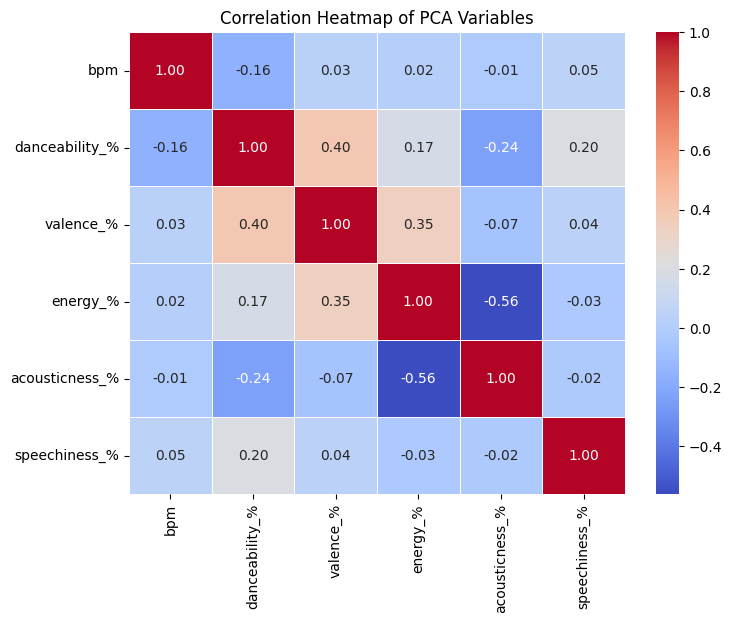

In [69]:
# Check correlations for bpm, danceability_%, valence_%, energy_%, acousticness_%, speechiness_%

# Select the columns for PCA
pca_cols = ['bpm', 'danceability_%', 'valence_%', 'energy_%', 'acousticness_%', 'speechiness_%']
df_pca = df[pca_cols]

# Calculate the correlation matrix
correlation_matrix = df_pca.corr()

# Display the correlation matrix
print("Correlation Matrix for PCA Variables:")
print(correlation_matrix)

# Optionally visualize the correlation matrix with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of PCA Variables')
plt.show()

I would retain **4** of the **6** principal components, specifically the danceability_%,valence_%, acousticness_%, and speechiness_%. The reason for I would retain these specific 4 components is because I have grouped them into in two categories, either bmp/energy or the remainder 4. Grouping them this way made the most sense to me.